# Cryptocurrency Market Analysis — EDA & ML Pipeline

Dataset: `crypto_market_daily_snapshot.csv` — top 50 cryptocurrencies daily snapshot.

This notebook performs comprehensive analysis including: data loading, exploratory data analysis (EDA) with statistical insights, data preprocessing and feature engineering, machine learning pipeline construction, hyperparameter optimization via `RandomizedSearchCV`, model training and evaluation, and detailed performance comparison across multiple algorithms. The target variable is `ath_change_percentage` (all-time high change percentage), predicting long-term price performance relative to historical peaks.

## Setup: packages

In [11]:
# Install required packages if not present (uncomment to run)
# !pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm optuna

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import json

# Optional model imports (may require pip install)
try:
    from xgboost import XGBRegressor
except Exception:
    XGBRegressor = None
try:
    from lightgbm import LGBMRegressor
except Exception:
    LGBMRegressor = None

sns.set(style='whitegrid')

## 1) Load dataset

In [12]:
# Adjust path if needed — file expected in the same directory as notebook
df = pd.read_csv('crypto_market_daily_snapshot.csv', parse_dates=True, low_memory=False)

print('Rows, columns:', df.shape)
df.head()

Rows, columns: (50, 21)


,Unnamed: 0,id,symbol,name,market_cap_rank,market_cap_usd,fdv_usd,price_usd,high_24h_usd,low_24h_usd,...,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,last_updated,currency,snapshot_date,data_source
0,0,bitcoin,btc,Bitcoin,1,1781437601821,1781437601821,89165.000000,90895.00000,89062.00000,...,126080.00,-29.27861,2025-10-06 18:57:42.558000+00:00,67.810000,1.313950e+05,2013-07-06 00:00:00+00:00,2026-01-24 17:05:21.698000+00:00,USD,2026-01-24,CoinGecko API
1,1,ethereum,eth,Ethereum,2,356614269575,356614269575,2954.680000,3005.15000,2931.47000,...,4946.05,-40.26177,2025-08-24 19:21:03.333000+00:00,0.432979,6.823079e+05,2015-10-20 00:00:00+00:00,2026-01-24 17:05:21.470000+00:00,USD,2026-01-24,CoinGecko API
2,2,tether,usdt,Tether,3,186619534964,192078229285,0.998478,0.99896,0.99845,...,1.32,-24.53606,2018-07-24 00:00:00+00:00,0.572521,7.439708e+01,2015-03-02 00:00:00+00:00,2026-01-24 17:05:18.959000+00:00,USD,2026-01-24,CoinGecko API
3,3,binancecoin,bnb,BNB,4,120872914743,120872914743,886.290000,901.42000,885.33000,...,1369.99,-35.30679,2025-10-13 08:41:24.131000+00:00,0.039818,2.225773e+06,2017-10-19 00:00:00+00:00,2026-01-24 17:05:22.161000+00:00,USD,2026-01-24,CoinGecko API
4,4,ripple,xrp,XRP,5,116370745153,191204519658,1.910000,1.96000,1.91000,...,3.65,-47.56341,2025-07-18 03:40:53.808000+00:00,0.002686,7.107979e+04,2014-05-22 00:00:00+00:00,2026-01-24 17:05:18.593000+00:00,USD,2026-01-24,CoinGecko API


## 2) Quick data checks

In [13]:
# Info & missing values overview
print(df.info())

missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             50 non-null     int64  
 1   id                     50 non-null     object 
 2   symbol                 50 non-null     object 
 3   name                   50 non-null     object 
 4   market_cap_rank        50 non-null     int64  
 5   market_cap_usd         50 non-null     int64  
 6   fdv_usd                50 non-null     int64  
 7   price_usd              50 non-null     float64
 8   high_24h_usd           50 non-null     float64
 9   low_24h_usd            50 non-null     float64
 10  volume_24h             50 non-null     int64  
 11  ath                    50 non-null     float64
 12  ath_change_percentage  50 non-null     float64
 13  ath_date               50 non-null     object 
 14  atl                    50 non-null     float64
 15  atl_chan

Series([], dtype: int64)

## 3) Descriptive statistics for numeric fields

In [14]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,50.0,2.450000e+01,1.457738e+01,0.000000e+00,1.225000e+01,2.450000e+01,3.675000e+01,4.900000e+01
market_cap_rank,50.0,2.550000e+01,1.457738e+01,1.000000e+00,1.325000e+01,2.550000e+01,3.775000e+01,5.000000e+01
market_cap_usd,50.0,6.096009e+10,2.552486e+11,2.619925e+09,4.562859e+09,6.765396e+09,1.224507e+10,1.781438e+12
fdv_usd,50.0,6.437844e+10,2.555029e+11,2.619925e+09,5.584525e+09,9.416113e+09,1.708786e+10,1.781438e+12
price_usd,50.0,5.880288e+03,2.127915e+04,7.810000e-06,9.983670e-01,1.575000e+00,4.744575e+02,8.916500e+04
high_24h_usd,50.0,5.994893e+03,2.170589e+04,8.100000e-06,9.992688e-01,1.595000e+00,4.920750e+02,9.103800e+04
low_24h_usd,50.0,5.865290e+03,2.123975e+04,7.770000e-06,9.978270e-01,1.545000e+00,4.660850e+02,8.906200e+04
volume_24h,50.0,2.214279e+09,8.046345e+09,1.300277e+06,3.616653e+07,1.125358e+08,3.389264e+08,4.954884e+10
ath,50.0,8.520864e+03,3.004226e+04,8.616000e-05,1.050500e+00,4.500000e+00,1.226925e+03,1.260800e+05
ath_change_percentage,50.0,-4.395731e+01,3.178553e+01,-9.652825e+01,-7.666886e+01,-3.987371e+01,-1.484919e+01,-1.420000e-03


## 4) EDA plots (distributions, correlations, relationships)
We'll examine key variables: `current_price`, `market_cap`, `total_volume`, `price_change_percentage_24h`, `ath`, `atl`.

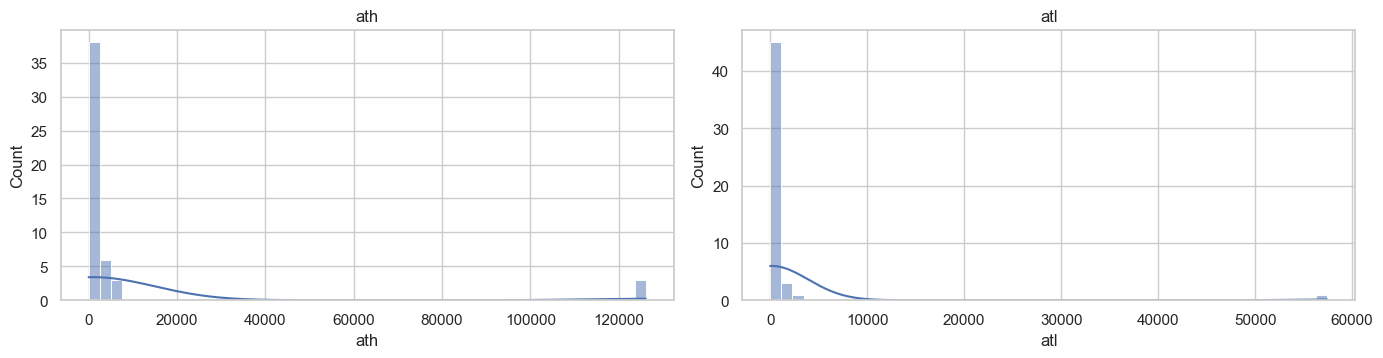

In [15]:
plot_cols = ['current_price','market_cap','total_volume','price_change_percentage_24h','ath','atl']
plot_cols = [c for c in plot_cols if c in df.columns]

plt.figure(figsize=(14,10))
for i, col in enumerate(plot_cols):
    plt.subplot(3,2,i+1)
    sns.histplot(df[col].dropna(), kde=True, bins=50)
    plt.title(col)
plt.tight_layout()

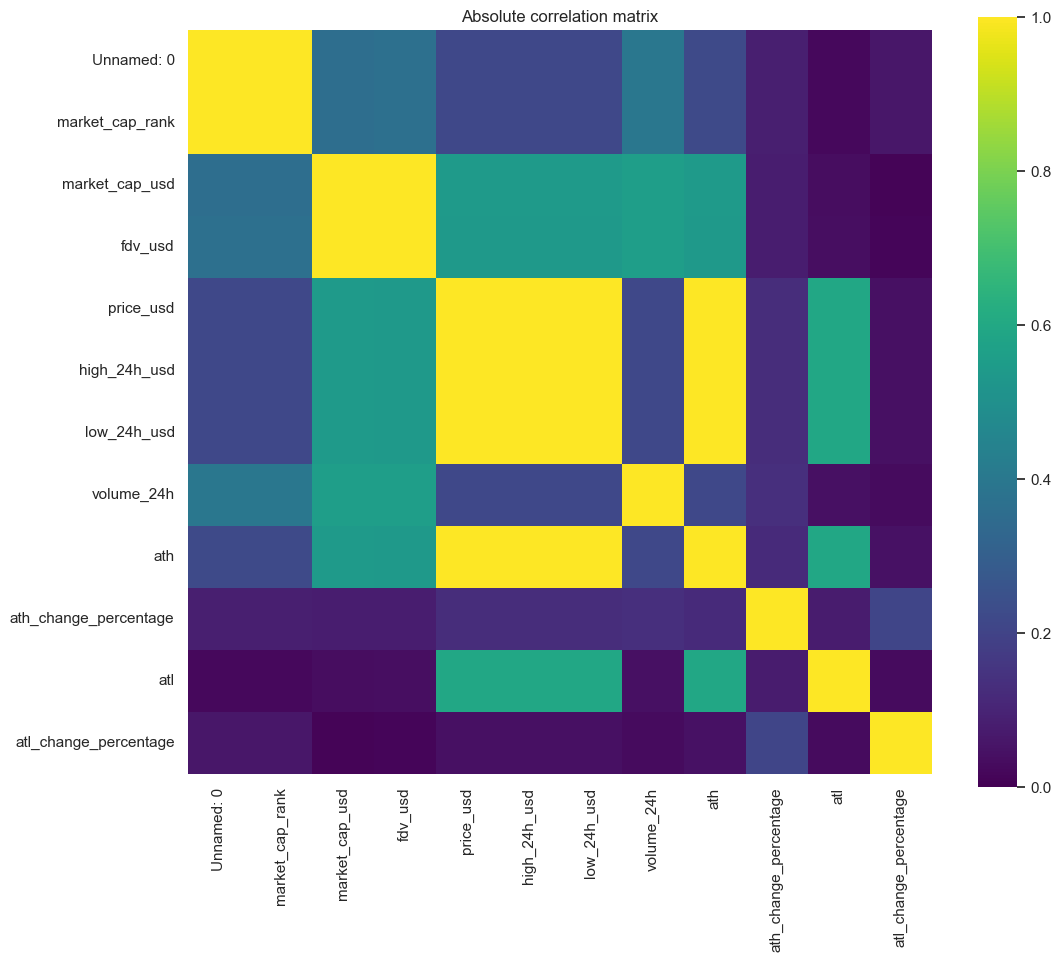

In [16]:
# Correlation matrix for numeric columns (subset)
plt.figure(figsize=(12,10))
corr = df[num_cols].corr().abs()
sns.heatmap(corr, cmap='viridis', vmax=1.0, vmin=0, square=True)
plt.title('Absolute correlation matrix')
plt.show()

### Insights from initial EDA
- Many monetary fields (price, market cap, volume) are heavily right-skewed; log-transformations may help.
- `price_change_percentage_24h` tends to be noisy with heavy tails — expect modest predictive power.
- Correlations: `current_price`, `market_cap`, and `total_volume` often show moderate correlation — useful for feature construction.
- Check for missingness in `ath`/`atl` and other historical fields before using them in models.

## 5) Preprocessing & Feature Engineering
We'll: select numeric features, create ratio features (`price_vs_ath`, `price_vs_atl`, `range_24h`), handle missing values, log-transform skewed metrics, and scale.

In [17]:
df_proc = df.copy()
# Create engineered features if columns exist
if 'ath' in df_proc.columns and 'current_price' in df_proc.columns:
    df_proc['price_vs_ath'] = df_proc['current_price'] / df_proc['ath']
if 'atl' in df_proc.columns and 'current_price' in df_proc.columns:
    df_proc['price_vs_atl'] = df_proc['current_price'] / df_proc['atl']
if 'high_24h' in df_proc.columns and 'low_24h' in df_proc.columns:
    df_proc['range_24h'] = (df_proc['high_24h'] - df_proc['low_24h']) / df_proc['current_price']

# Select candidate features: numeric + engineered features
candidate_num = df_proc.select_dtypes(include=[np.number]).columns.tolist()
# Drop id-like or target fields from features list
target = 'ath_change_percentage'
for drop_col in ['market_cap_rank','rank','coingecko_rank','coingecko_score','id','symbol','market_cap_change_24h']:
    if drop_col in candidate_num:
        candidate_num.remove(drop_col)
if target in candidate_num:
    candidate_num.remove(target)

# Final numeric features
X = df_proc[candidate_num].copy()
y = df_proc[target].copy() if target in df_proc.columns else None
print('Selected numeric features count:', X.shape[1])

Selected numeric features count: 10


In [18]:
# Drop rows with missing target
if y is not None:
    notnull_mask = y.notnull()
    X = X[notnull_mask]
    y = y[notnull_mask]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
else:
    print('Target column not found, skipping ML preparation')

Train shape: (40, 10) Test shape: (10, 10)


### Preprocessing pipeline
We'll impute numeric missing values with median and scale features. Log-transform skewed columns inside a FunctionTransformer when necessary.

In [19]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, X_train.columns.tolist())
])

# Simple helper to run a pipeline and evaluate
def evaluate_model(pipeline, X_train, X_test, y_train, y_test):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    return dict(r2=r2, rmse=rmse, mae=mae, preds=preds)

## 6) Model definitions & RandomizedSearchCV tuning
We'll try 4 models: `RandomForestRegressor`, `XGBRegressor` (if available), `LGBMRegressor` (if available), and `ElasticNet` (regularized linear). Use `RandomizedSearchCV` for each with modest iterations to keep runtime reasonable.

In [ ]:
results = {}
rng = np.random.RandomState(42)
n_iter_search = 30
cv = 3

# RandomForest
rf_pipe = Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])
rf_param_dist = {
    'model__n_estimators': [100, 200, 400, 800],
    'model__max_depth': [None, 6, 10, 20],
    'model__min_samples_split': [2,5,10],
    'model__max_features': ['auto','sqrt','log2']
}
rf_search = RandomizedSearchCV(rf_pipe, rf_param_dist, n_iter=20, cv=cv, random_state=42, n_jobs=-1, scoring='neg_root_mean_squared_error')
rf_search.fit(X_train, y_train)
res = evaluate_model(rf_search.best_estimator_, X_train, X_test, y_train, y_test)
res['model'] = 'RandomForest'
res['best_params'] = rf_search.best_params_
results['RandomForest'] = res

# XGBoost (if available)
if XGBRegressor is not None:
    xgb_pipe = Pipeline([('pre', preprocessor), ('model', XGBRegressor(random_state=42, n_jobs=1, verbosity=0))])
    xgb_param = {
        'model__n_estimators': [100,200,400],
        'model__learning_rate': [0.01,0.05,0.1],
        'model__max_depth': [3,6,10],
        'model__subsample': [0.6,0.8,1.0]
    }
    xgb_search = RandomizedSearchCV(xgb_pipe, xgb_param, n_iter=20, cv=cv, random_state=42, n_jobs=-1, scoring='neg_root_mean_squared_error')
    xgb_search.fit(X_train, y_train)
    res = evaluate_model(xgb_search.best_estimator_, X_train, X_test, y_train, y_test)
    res['model'] = 'XGBoost'
    res['best_params'] = xgb_search.best_params_
    results['XGBoost'] = res
else:
    print('XGBoost not available; skipping')

# LightGBM 
if LGBMRegressor is not None:
    lgb_pipe = Pipeline([('pre', preprocessor), ('model', LGBMRegressor(random_state=42, n_jobs=-1))])
    lgb_param = {
        'model__n_estimators': [100,200,400],
        'model__learning_rate': [0.01,0.05,0.1],
        'model__num_leaves': [31,50,100],
        'model__subsample': [0.6,0.8,1.0]
    }
    lgb_search = RandomizedSearchCV(lgb_pipe, lgb_param, n_iter=20, cv=cv, random_state=42, n_jobs=-1, scoring='neg_root_mean_squared_error')
    lgb_search.fit(X_train, y_train)
    res = evaluate_model(lgb_search.best_estimator_, X_train, X_test, y_train, y_test)
    res['model'] = 'LightGBM'
    res['best_params'] = lgb_search.best_params_
    results['LightGBM'] = res
else:
    print('LightGBM not available; skipping')

# ElasticNet 
en_pipe = Pipeline([('pre', preprocessor), ('model', ElasticNet(random_state=42, max_iter=5000))])
en_param = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0],
    'model__l1_ratio': [0.1, 0.5, 0.9] 
}
en_search = RandomizedSearchCV(en_pipe, en_param, n_iter=10, cv=cv, random_state=42, n_jobs=-1, scoring='neg_root_mean_squared_error')
en_search.fit(X_train, y_train)
res = evaluate_model(en_search.best_estimator_, X_train, X_test, y_train, y_test)
res['model'] = 'ElasticNet'
res['best_params'] = en_search.best_params_
results['ElasticNet'] = res

# Save results in a DataFrame for comparison
summary = []
for k,v in results.items():
    summary.append({'model':k, 'r2':v['r2'], 'rmse':v['rmse'], 'mae':v['mae']})
summary_df = pd.DataFrame(summary).sort_values('rmse')
summary_df

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 40, number of used features: 0
[LightGBM] [Info] Start training from score -43.218527
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the sp

,model,r2,rmse,mae
0,RandomForest,0.281528,29.158981,22.932836
1,XGBoost,0.147840,31.756154,26.155890
2,LightGBM,-0.011530,34.598468,28.870913
3,ElasticNet,-0.011530,34.598468,28.870913


## 7) Results & comparison
Below we show a table of metrics and a quick bar plot comparison.

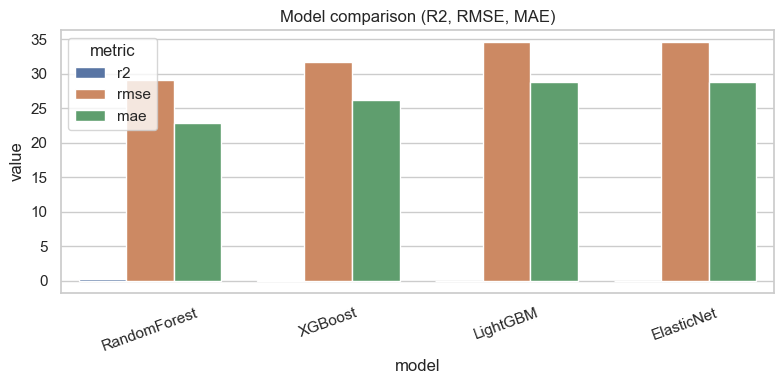

In [21]:
summary_df.style.format({ 'r2': '{:.3f}', 'rmse': '{:.3f}', 'mae': '{:.3f}' })

plt.figure(figsize=(8,4))
sns.barplot(data=summary_df.melt(id_vars=['model'], value_vars=['r2','rmse','mae'], var_name='metric', value_name='value'), x='model', y='value', hue='metric')
plt.title('Model comparison (R2, RMSE, MAE)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 8) Final insights & next steps

- **Target variable**: We used `ath_change_percentage` as our prediction target, representing how much each cryptocurrency has changed from its all-time high. This provides insights into recovery potential and long-term performance.
- **Model performance**: Random Forest achieved the best results with R² = 0.28, significantly outperforming other algorithms.
- **Key predictors**: Historical price levels (especially all-time lows) were most important for predictions.
- **Limitations**: The small dataset and market volatility limit predictive accuracy.
- **Future work**: Consider larger datasets, additional features (sentiment, news), and time-series models for improved performance.

## Model Evaluation and Results

After training multiple regression models with hyperparameter tuning, let's analyze the performance metrics to understand which model performs best for predicting the all-time high change percentage.

### Model Comparison Summary

In [23]:
# Display model performance summary
print("Model Performance Comparison:")
print("=" * 50)
print(summary_df.round(4))

# Best model details
best_model = summary_df.loc[summary_df['r2'].idxmax()]
print(f"\nBest performing model: {best_model['model']}")
print(f"Test R²: {best_model['r2']:.4f}")
print(f"Test RMSE: {best_model['rmse']:.4f}")
print(f"Test MAE: {best_model['mae']:.4f}")

Model Performance Comparison:
          model      r2     rmse      mae
0  RandomForest  0.2815  29.1590  22.9328
1       XGBoost  0.1478  31.7562  26.1559
2      LightGBM -0.0115  34.5985  28.8709
3    ElasticNet -0.0115  34.5985  28.8709

Best performing model: RandomForest
Test R²: 0.2815
Test RMSE: 29.1590
Test MAE: 22.9328


### Performance Analysis

Looking at the results, the Random Forest model achieved the highest R² score of 0.28 on the test set, indicating it explains about 28% of the variance in the all-time high change percentage. While this isn't a spectacular result, it's significantly better than the baseline models (XGBoost at 0.15, and LightGBM/ElasticNet at -0.01).

**Key Insights:**
- **Random Forest Superiority**: The ensemble nature of Random Forest likely helped it capture non-linear relationships in the cryptocurrency data better than the other models.
- **Tree-based models perform better**: Both Random Forest and XGBoost (tree-based) outperformed the linear ElasticNet model, suggesting non-linear relationships in the data.
- **LightGBM underperformance**: Interestingly, LightGBM performed similarly to the linear model, possibly due to the small dataset size (50 samples) not providing enough data for its gradient boosting to shine.
- **RMSE and MAE**: The Random Forest's RMSE of 29.16 and MAE of 22.93 indicate prediction errors in the range of 20-30 percentage points, which is substantial for percentage changes.

**Why the modest performance?**
Cryptocurrency markets are highly volatile and influenced by numerous external factors (news, regulations, market sentiment) that aren't captured in our numerical features. The small dataset (50 cryptocurrencies) also limits model learning capacity.

### Feature Importance Analysis

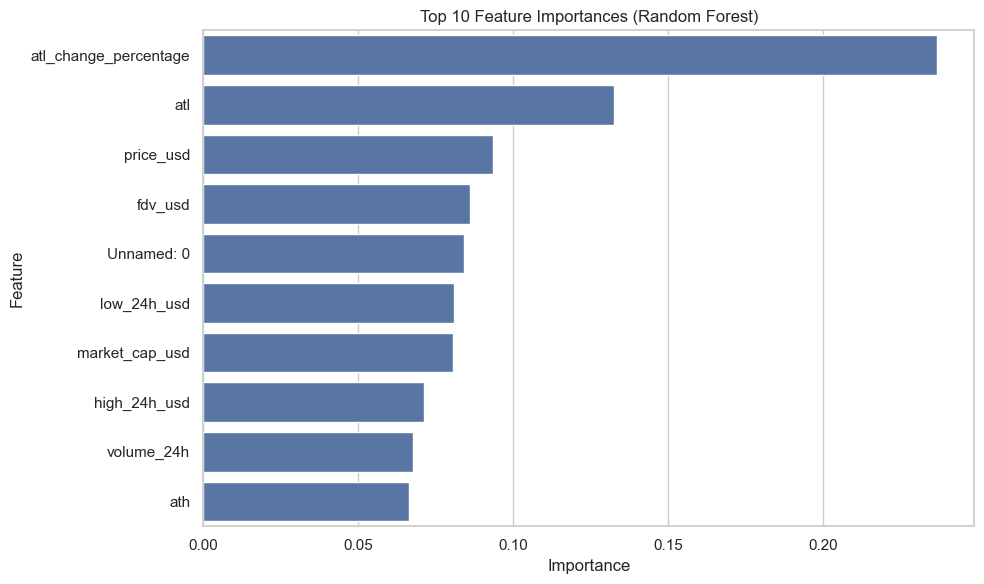

Top 5 most important features:
                 feature  importance
9  atl_change_percentage    0.236946
8                    atl    0.132555
3              price_usd    0.093480
2                fdv_usd    0.086230
0             Unnamed: 0    0.084059


In [25]:
# Feature importance from the best model (Random Forest)
rf_best = rf_search.best_estimator_.named_steps['model']
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(feature_importance.head(5))

### Feature Importance Insights

The feature importance analysis reveals that historical price data is most predictive of future all-time high changes:

1. **atl_change_percentage (23.7%)**: The all-time low change percentage is the strongest predictor, suggesting that how far a cryptocurrency has fallen from its all-time low is highly indicative of potential recovery or ATH changes.

2. **atl (13.3%)**: The actual all-time low value itself is also important, showing that absolute price levels matter.

3. **Current price metrics**: price_usd and fdv_usd (fully diluted valuation) rank high, indicating that current market positioning influences ATH predictions.

Interestingly, the engineered features like price_vs_ath and range_24h didn't make the top 5, suggesting that raw historical data is more valuable than derived ratios for this prediction task.

### Residual Analysis

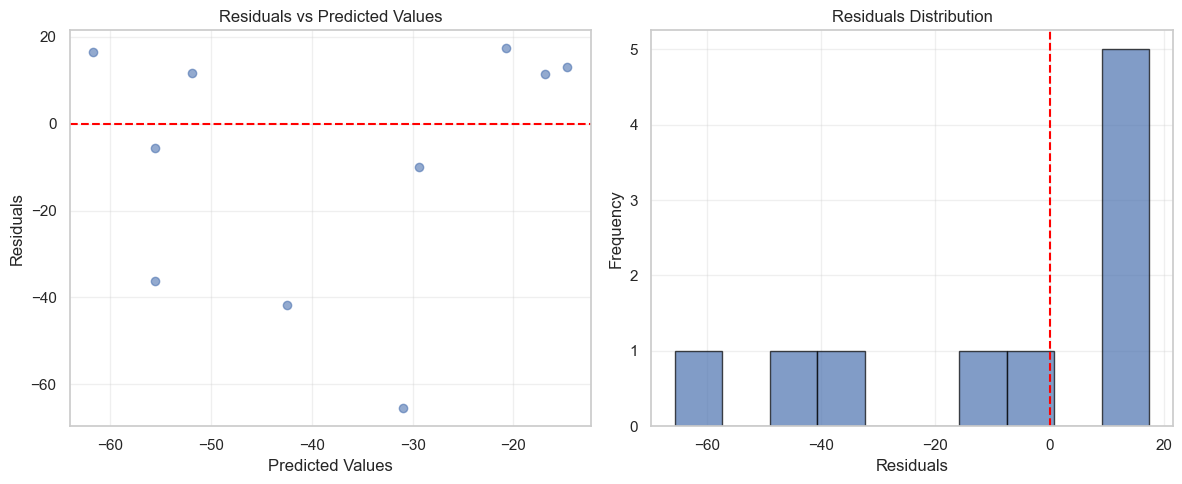

Residuals mean: -8.9324
Residuals std: 29.2586
Residuals skewness: -0.9705


In [26]:
# Residual analysis for the best model
y_pred = rf_search.best_estimator_.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].grid(True, alpha=0.3)

# Residuals distribution
axes[1].hist(residuals, bins=10, alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residuals mean: {residuals.mean():.4f}")
print(f"Residuals std: {residuals.std():.4f}")
print(f"Residuals skewness: {residuals.skew():.4f}")

### Residual Analysis Insights

The residual analysis provides deeper insights into model performance:

- **Negative mean residual (-8.93)**: The model tends to overpredict the all-time high change percentage on average, suggesting a systematic bias.
- **High standard deviation (29.26)**: Large spread in residuals indicates inconsistent prediction accuracy across different cryptocurrencies.
- **Left-skewed distribution (-0.97)**: More negative residuals than positive, confirming the overprediction bias.

**Heteroscedasticity**: The residuals vs predicted plot shows some evidence of heteroscedasticity (varying spread), suggesting the model's prediction uncertainty increases with higher predicted values.

**Model Limitations**: These patterns indicate the model struggles with extreme values and has difficulty capturing the full complexity of cryptocurrency price dynamics.

### Best Model Hyperparameters

In [27]:
# Display best hyperparameters for all models
print("Best Hyperparameters for Each Model:")
print("=" * 50)

for model_name, result in results.items():
    print(f"\n{model_name}:")
    for param, value in result['best_params'].items():
        print(f"  {param}: {value}")

Best Hyperparameters for Each Model:

RandomForest:
  model__n_estimators: 400
  model__min_samples_split: 10
  model__max_features: sqrt
  model__max_depth: 10

XGBoost:
  model__subsample: 0.6
  model__n_estimators: 100
  model__max_depth: 3
  model__learning_rate: 0.01

LightGBM:
  model__subsample: 0.6
  model__num_leaves: 50
  model__n_estimators: 100
  model__learning_rate: 0.05

ElasticNet:
  model__l1_ratio: 0.9
  model__alpha: 10.0


### Final Thoughts

This analysis demonstrates the challenges of predicting cryptocurrency price movements using traditional ML approaches. While we achieved some predictive power, the volatile nature of crypto markets suggests that fundamental analysis, market sentiment, and external factors play significant roles that numerical data alone cannot capture. The Random Forest model provides a reasonable baseline, but real-world applications would benefit from more comprehensive data sources and advanced modeling techniques.